## Stanisław Wojciechowski
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vyenn/ML2024/blob/main/homework5.ipynb)

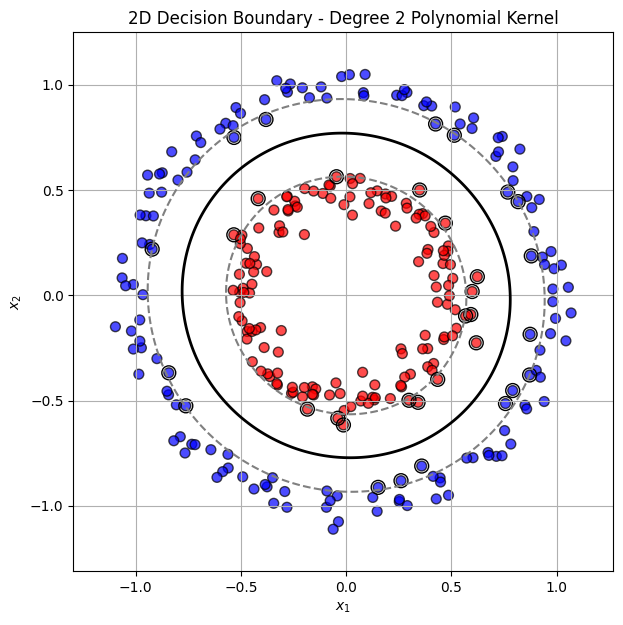

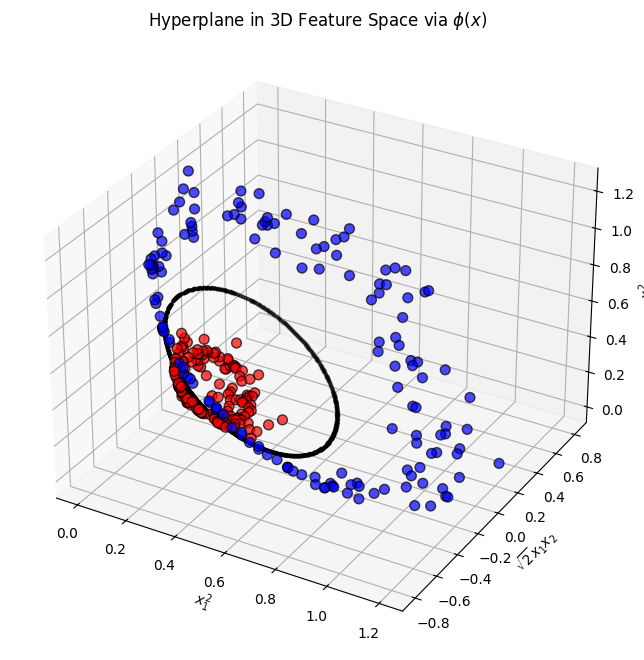

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from mpl_toolkits.mplot3d import Axes3D

# Generate Non-linearly Separable Data
np.random.seed(42)
X, y = make_circles(n_samples=300, factor=0.5, noise=0.05)
y = np.where(y == 0, -1, 1)

# Train SVM with Degree-2 Polynomial Kernel
clf = SVC(kernel='poly', degree=2, C=1.0, coef0=0, gamma=1)
clf.fit(X, y)

# Visualize Decision Boundary in 2D
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
grid = np.c_[xx.ravel(), yy.ravel()]
decision = clf.decision_function(grid).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7)
plt.contour(xx, yy, decision, levels=[0], linewidths=2, colors='k')
plt.contour(xx, yy, decision, levels=[-1, 1], linestyles='--', colors='grey')
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100, linewidth=1, facecolors='none', edgecolors='k')
plt.title('2D Decision Boundary - Degree 2 Polynomial Kernel')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid(True)
plt.gca().set_aspect('equal')
plt.show()

# Map Data Using Explicit Feature Mapping $ϕ(x) = [x_1^2, \sqrt{2}x_1x_2, x_2^2]$
phi = lambda x: np.array([x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2])
phi_X = np.array([phi(x) for x in X])
phi_grid = np.array([phi(x) for x in grid])

# Visualize Decision Boundary in 3D Feature Space
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(phi_X[:, 0], phi_X[:, 1], phi_X[:, 2], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7)

# Highlight decision boundary in feature space
grid_decision = clf.decision_function(grid)
contour_mask = np.isclose(grid_decision, 0, atol=0.01)
ax.scatter(phi_grid[contour_mask, 0], phi_grid[contour_mask, 1], phi_grid[contour_mask, 2], c='k', s=5)

ax.set_title('Hyperplane in 3D Feature Space via $\phi(x)$')
ax.set_xlabel('$x_1^2$')
ax.set_ylabel('$\sqrt{2} x_1 x_2$')
ax.set_zlabel('$x_2^2$')
plt.show()

## Answers

**Why does the SVM's decision boundary in the higher-dimensional (3D) feature space not look like a “flat” hyperplane, even though we know the classifier’s separating surface is mathematically linear in that space?**
- Although the SVM constructs a linear hyperplane in the 3D feature space, the map $\phi$ that maps the input space there, is a **non-linear transformation**.

**Explain why a hyperplane in 3D becomes a circular (or elliptical) curve when viewed back in the original 2D plane of the dataset.**
- a map $\phi$ is quadratic, its image is a cone. That's why when intersected with a hyperplane, we expect to see a circle,ellpise,parabola or a hyperbola.